<a href="https://colab.research.google.com/github/saim9211/Machine-Learning-Stuff/blob/main/Func_Power_transformation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
df=pd.read_csv('train (1).csv',usecols=['Age','Fare','Survived'])
df.sample(2)

,Survived,Age,Fare
493,0,71.0,49.5042
59,0,11.0,46.9000


In [10]:
df.isnull().sum()

,0
Survived,0
Age,177
Fare,0


In [8]:
df['Age'].head()

,Age
0,22.0
1,38.0
2,26.0
3,35.0
4,35.0


In [18]:
df['Age']=df['Age'].fillna(df['Age'].mean())

In [19]:
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import cross_validate
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression


In [21]:
x_test,x_train,y_test,y_train=train_test_split(df.drop(columns=['Survived']),df['Survived'],test_size=0.2,random_state=42)

In [22]:
lg=LogisticRegression()

In [23]:
train_fit=lg.fit(x_train,y_train)
test_fit=lg.fit(x_test,y_test)

In [24]:
pred=lg.predict(x_test)


In [25]:
accuracy=accuracy_score(y_test,pred)
accuracy

0.6601123595505618

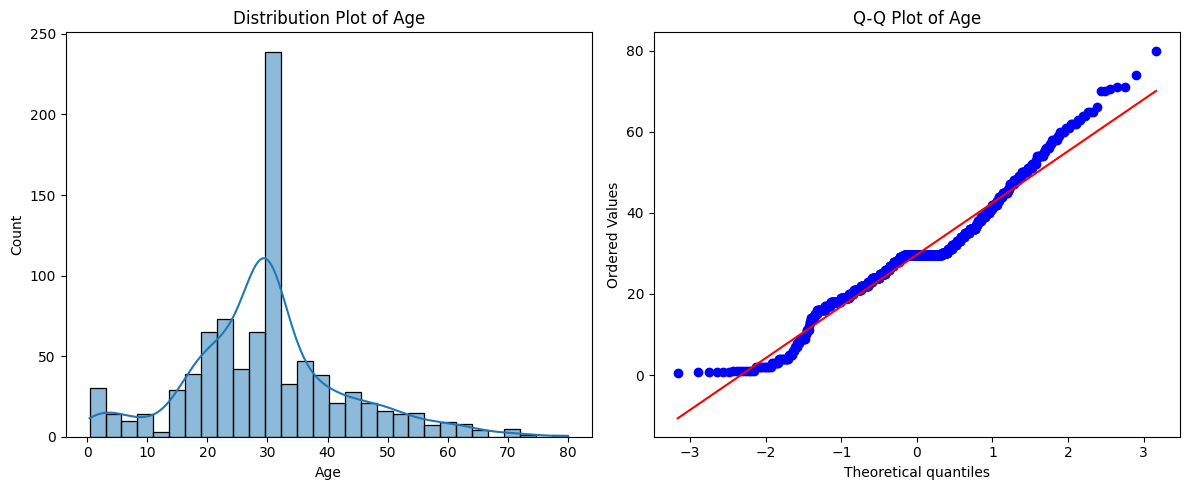

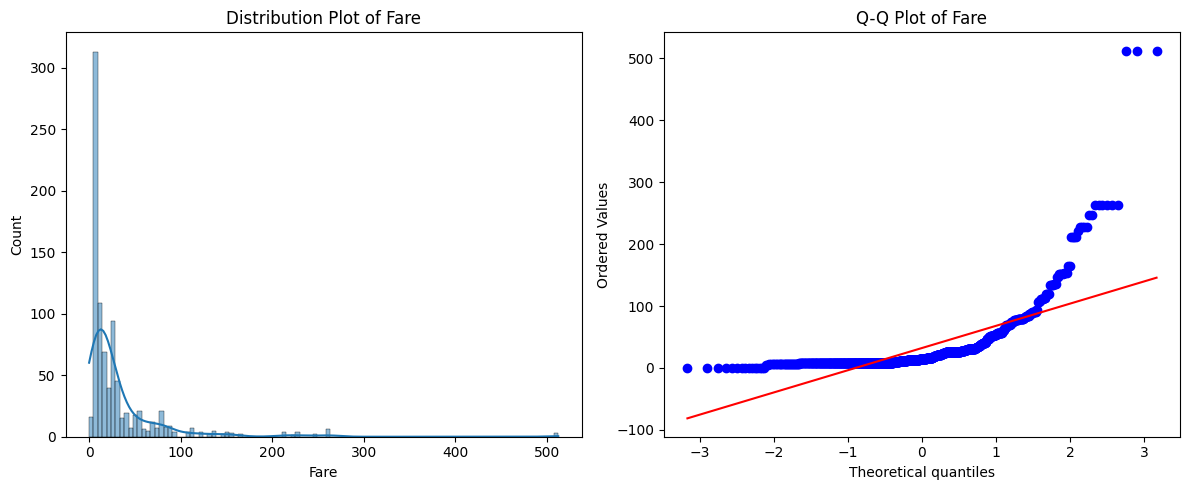


--- Plots for 'Survived' (binary variable) ---


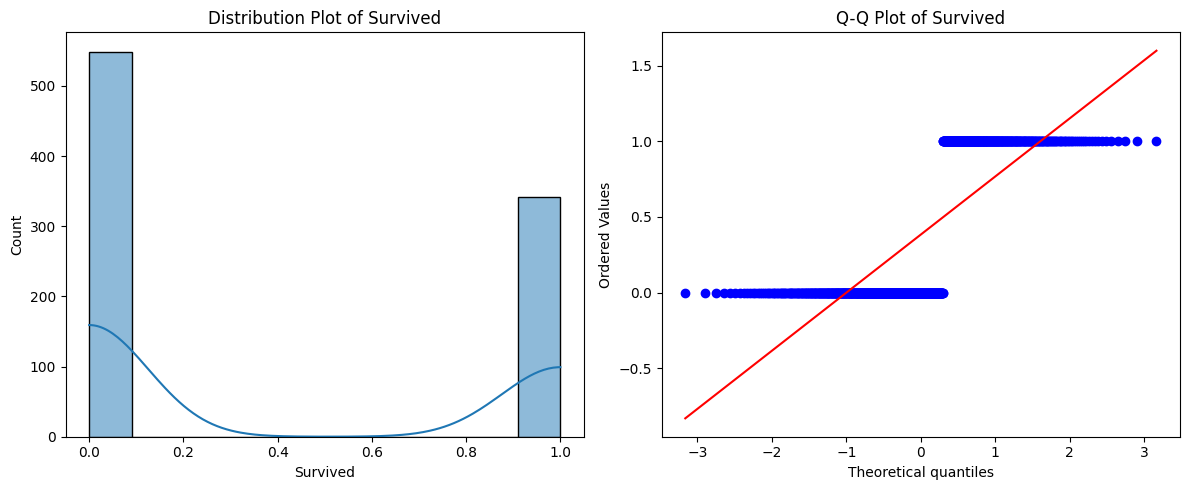

In [26]:
import scipy.stats as stats

def plot_distribution_and_qq(df, column):
    plt.figure(figsize=(12, 5))

    # Distribution plot
    plt.subplot(1, 2, 1)
    sns.histplot(df[column], kde=True)
    plt.title(f'Distribution Plot of {column}')

    # Q-Q plot
    plt.subplot(1, 2, 2)
    stats.probplot(df[column], dist="norm", plot=plt)
    plt.title(f'Q-Q Plot of {column}')

    plt.tight_layout()
    plt.show()

# Get numerical columns, excluding the target variable 'Survived' for typical distribution analysis
numerical_cols = ['Age', 'Fare']

for col in numerical_cols:
    plot_distribution_and_qq(df, col)

# Also show for 'Survived' as requested for each column, with a note on interpretation
print("\n--- Plots for 'Survived' (binary variable) ---")
plot_distribution_and_qq(df, 'Survived')

Let's check the skewness of the numerical columns.

In [27]:
print(df[['Age', 'Fare']].skew())

Age     0.434488
Fare    4.787317
dtype: float64


In [30]:
ft=FunctionTransformer(func=np.log1p)
ft

FunctionTransformer(func=<ufunc 'log1p'>)

In [33]:
x_train_tranfor=ft.fit_transform(x_train)
x_test_tranfor=ft.transform(x_test)


In [38]:
lg.fit(x_train_tranfor,y_train)
lg.fit(x_test_tranfor,y_test)

LogisticRegression()

In [40]:
pred_t=lg.predict(x_test_tranfor)

In [41]:
accuracy_t=accuracy_score(y_test,pred_t)
accuracy_t

0.6825842696629213

In [50]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(lg, x_train_tranfor, y_train, cv=5)

print(f"Cross-validation scores: {cv_scores}")
print(f"Mean cross-validation score: {cv_scores.mean():.5f}")
print(f"Standard deviation of cross-validation scores: {cv_scores.std():.5f}")

Cross-validation scores: [0.58333333 0.77777778 0.77777778 0.77777778 0.71428571]
Mean cross-validation score: 0.72619
Standard deviation of cross-validation scores: 0.07554


In [51]:
print(f"Mean cross-validation accuracy: {cv_scores.mean():.5f}")

Mean cross-validation accuracy: 0.72619



--- Plots for Transformed 'Age' ---


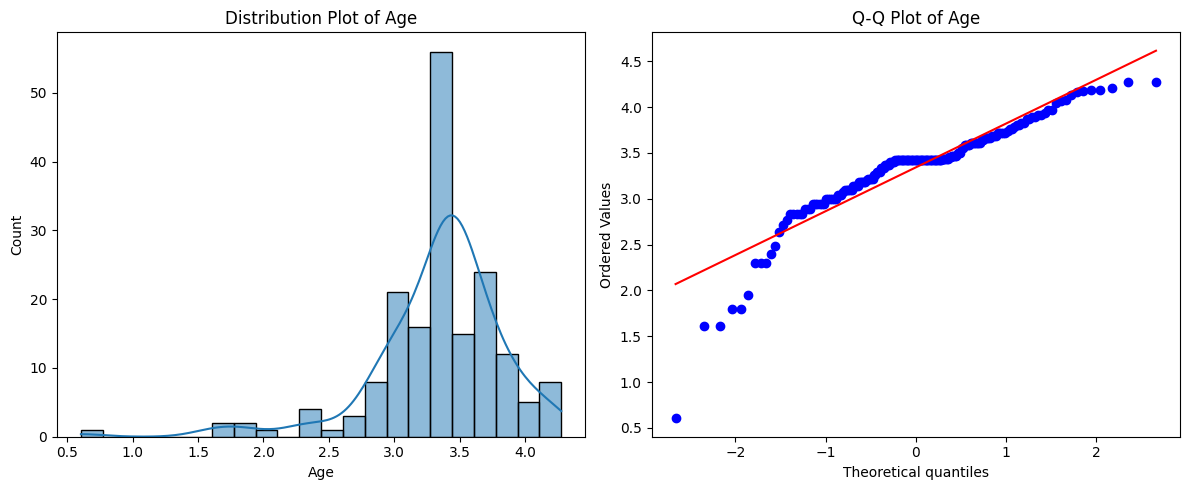


--- Plots for Transformed 'Fare' ---


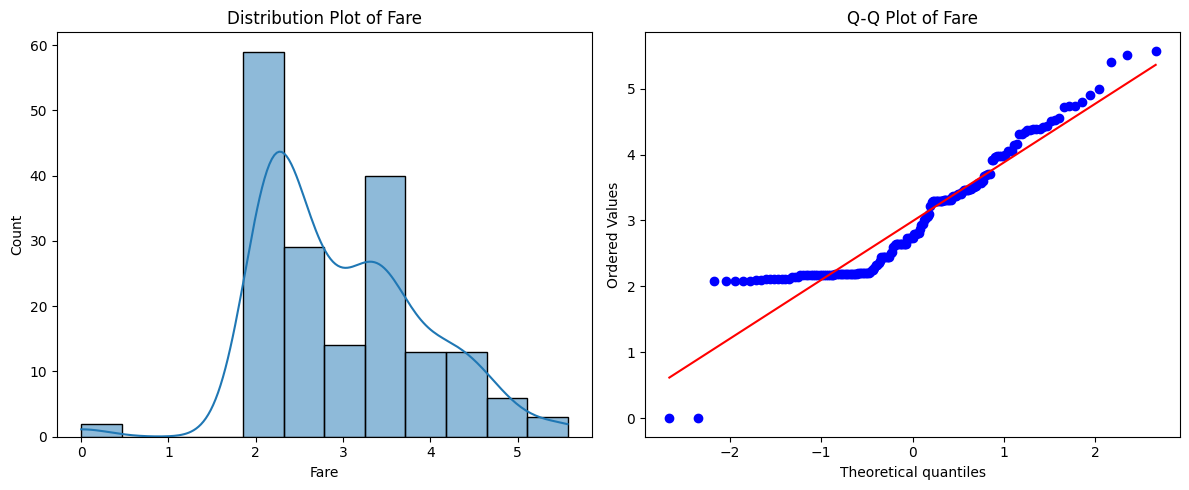

In [52]:
print("\n--- Plots for Transformed 'Age' ---")
plot_distribution_and_qq(x_train_tranfor, 'Age')

print("\n--- Plots for Transformed 'Fare' ---")
plot_distribution_and_qq(x_train_tranfor, 'Fare')

In [61]:
tf1=ColumnTransformer(transformers=[
    ('Function_transfer',FunctionTransformer(func=np.log1p),['Fare'])
]
)
tf1

ColumnTransformer(transformers=[('Function_transfer',
                                 FunctionTransformer(func=<ufunc 'log1p'>),
                                 ['Fare'])])

In [62]:
x_train_tranfered=tf1.fit_transform(x_train)
x_test_tranfered=tf1.transform(x_test)

In [63]:
lgs=LogisticRegression()

In [64]:
lgs.fit(x_train_tranfered,y_train)
lgs.fit(x_test_tranfered,y_test)

LogisticRegression()

In [65]:
pred=lgs.predict(x_test_tranfered)

In [66]:
accuracy=accuracy_score(y_test,pred)
accuracy

0.6713483146067416

In [68]:
cv_scores_lgs = cross_val_score(lgs, x_train_tranfered, y_train, cv=5)

print(f"Cross-validation scores for lgs: {cv_scores_lgs}")
print(f"Mean cross-validation score for lgs: {cv_scores_lgs.mean():.5f}")
print(f"Standard deviation of cross-validation scores for lgs: {cv_scores_lgs.std():.5f}")

Cross-validation scores for lgs: [0.61111111 0.69444444 0.72222222 0.66666667 0.74285714]
Mean cross-validation score for lgs: 0.68746
Standard deviation of cross-validation scores for lgs: 0.04602



--- Plots for Original Age ---


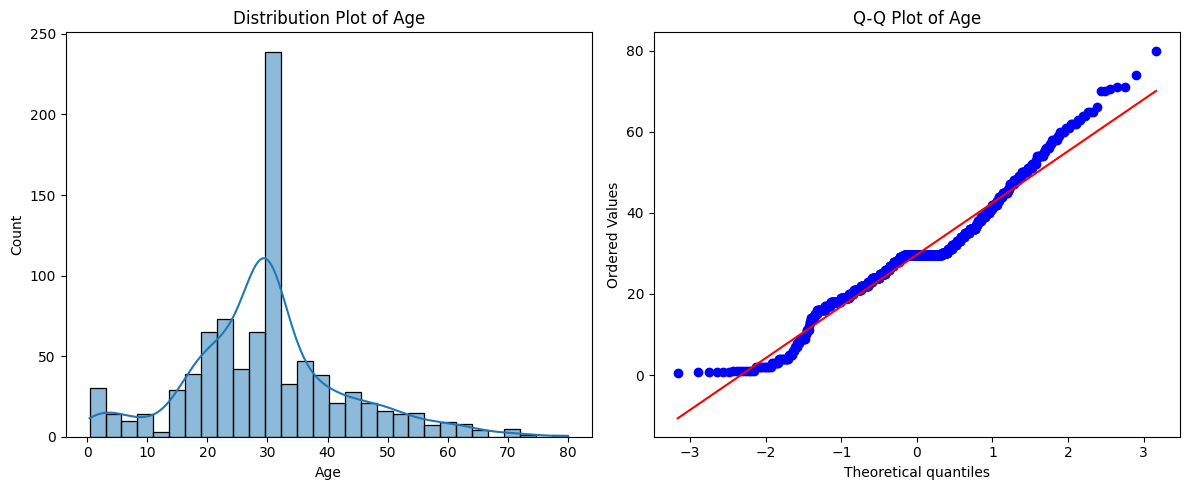


--- Plots for Original Fare ---


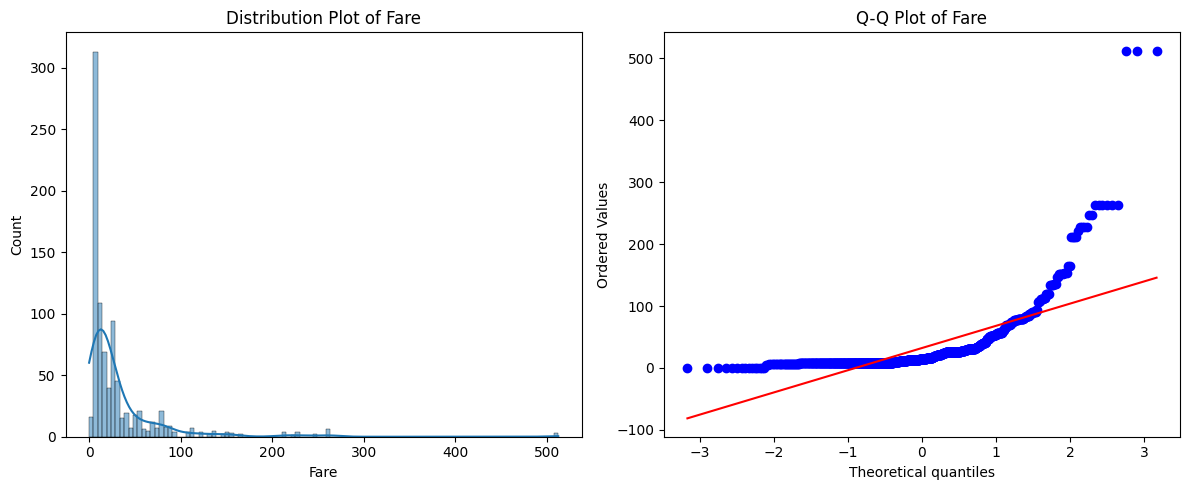

In [75]:
print('\n--- Plots for Original Age ---')
plot_distribution_and_qq(df, 'Age')

print('\n--- Plots for Original Fare ---')
plot_distribution_and_qq(df, 'Fare')

In [81]:
# The previous code had an IndexError because x_train_tranfered only contained the transformed 'Fare' column.
# To calculate the skewness of both 'Age' and 'Fare' after log1p transformation (from Scenario 1):
print(x_train_tranfor.skew())

Age    -1.689379
Fare    0.366900
dtype: float64



--- Plots for Transformed 'Age' ---


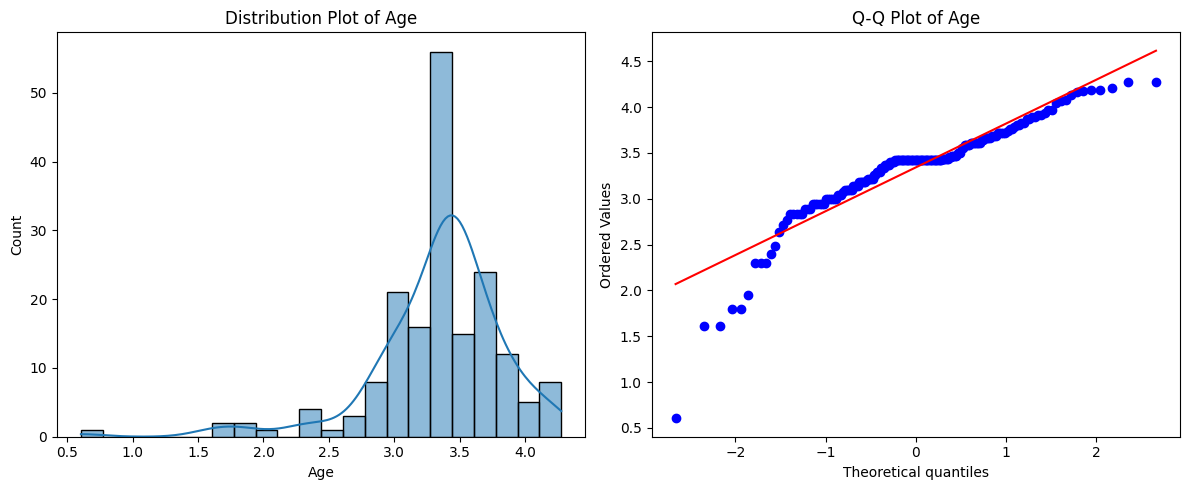


--- Plots for Transformed 'Fare' ---


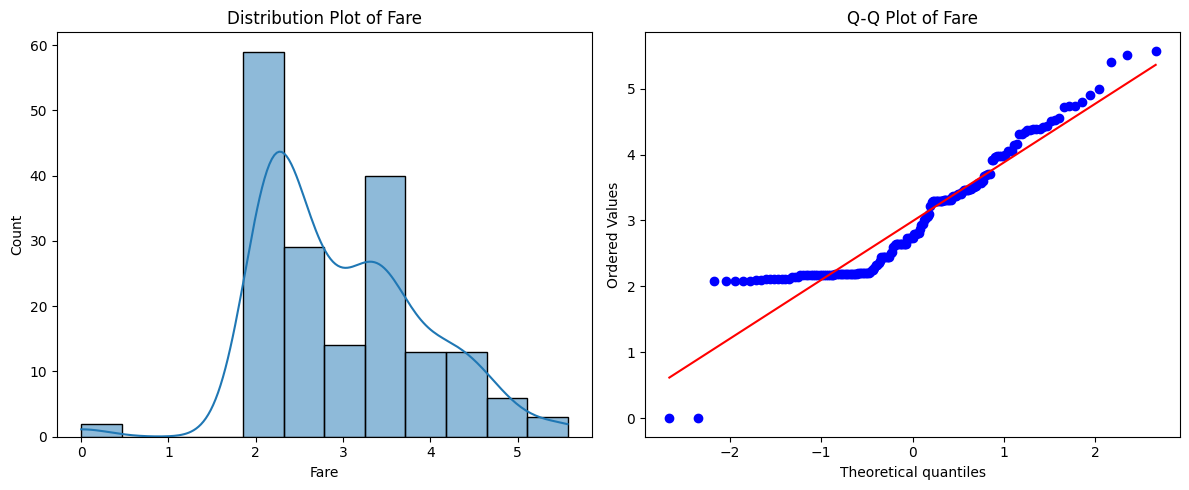

In [74]:
print("\n--- Plots for Transformed 'Age' ---")
plot_distribution_and_qq(x_train_tranfor, 'Age')

print("\n--- Plots for Transformed 'Fare' ---")
plot_distribution_and_qq(x_train_tranfor, 'Fare')

In [92]:
ft2=FunctionTransformer(func=lambda x: 1/(x + 1))

In [94]:
x_train_tranfered2=ft2.fit_transform(x_train)
x_test_tranfered2=ft2.transform(x_test)

In [95]:
lg2=LogisticRegression()
lg2.fit(x_train_tranfered2,y_train)
lg2.fit(x_test_tranfered2,y_test)

LogisticRegression()

In [96]:
pred_2=lg2.predict(x_test_tranfered2)

In [97]:
accuracy_score2=accuracy_score(y_test,pred_2)
accuracy_score2


0.6306179775280899

In [98]:
cv_scores_lg2 = cross_val_score(lg2, x_train_tranfered2, y_train, cv=5)

print(f"Cross-validation scores for lg2: {cv_scores_lg2}")
print(f"Mean cross-validation score for lg2: {cv_scores_lg2.mean():.5f}")
print(f"Standard deviation of cross-validation scores for lg2: {cv_scores_lg2.std():.5f}")

Cross-validation scores for lg2: [0.58333333 0.58333333 0.58333333 0.58333333 0.6       ]
Mean cross-validation score for lg2: 0.58667
Standard deviation of cross-validation scores for lg2: 0.00667


### Distribution and QQ Plots for `1/(x + 1)` Transformed Data


--- Plots for 1/(x+1) Transformed 'Age' ---


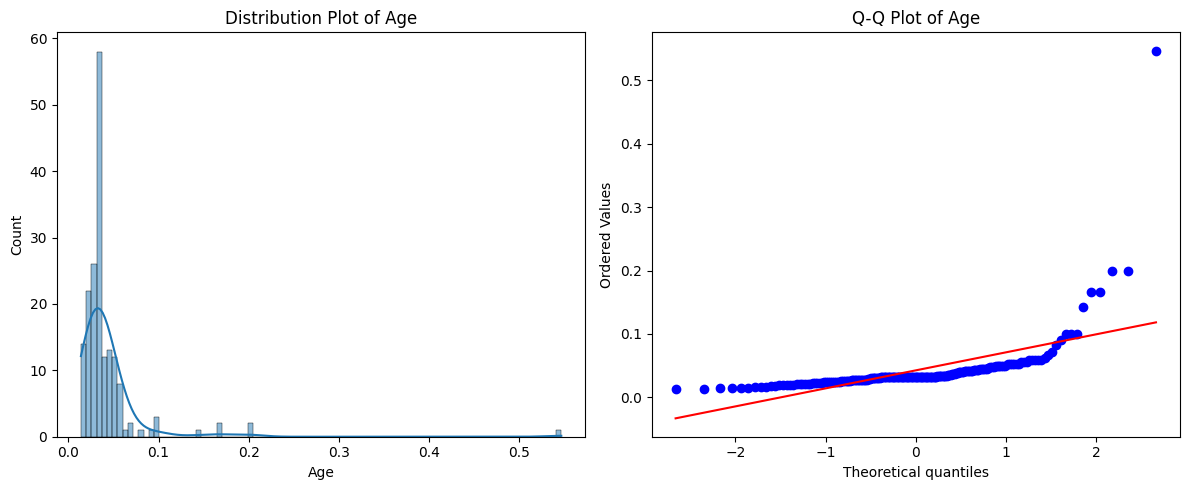


--- Plots for 1/(x+1) Transformed 'Fare' ---


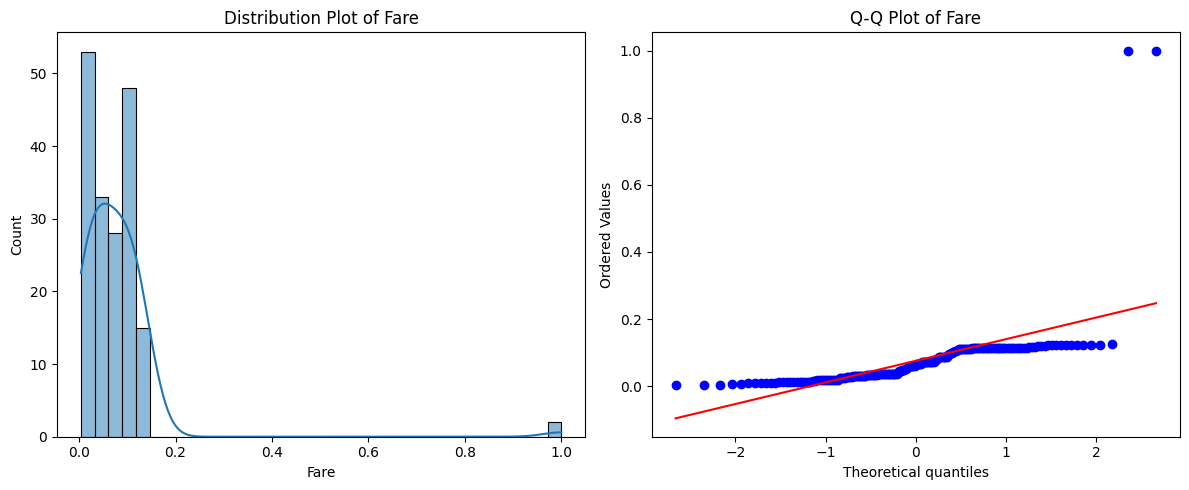

In [99]:
print("\n--- Plots for 1/(x+1) Transformed 'Age' ---")
plot_distribution_and_qq(x_train_tranfered2, 'Age')

print("\n--- Plots for 1/(x+1) Transformed 'Fare' ---")
plot_distribution_and_qq(x_train_tranfered2, 'Fare')

In [100]:


from sklearn.preprocessing import PowerTransformer

In [102]:
df=pd.read_csv('concrete_data.csv')
df.sample(3)

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
855,326.0,166.0,0.0,174.0,9.0,882.0,790.0,28,61.23
390,450.1,50.0,0.0,200.0,3.0,1124.4,613.2,28,39.38
357,277.2,97.8,24.5,160.7,11.2,1061.7,782.5,56,66.82


In [103]:
df.isnull().sum()

,0
Cement,0
Blast Furnace Slag,0
Fly Ash,0
Water,0
Superplasticizer,0
Coarse Aggregate,0
Fine Aggregate,0
Age,0
Strength,0


In [108]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
x_test,x_train,y_test,y_train=train_test_split(df.drop(columns=['Strength']),df['Strength'],test_size=0.2,random_state=42)

In [109]:
lr.fit(x_train,y_train)

LinearRegression()

In [111]:
y_pred = lr.predict(x_test)

In [117]:
r2_score(y_test,y_pred)

0.5490341502145725

In [122]:
pt=PowerTransformer(method='yeo-johnson')
x_train_tranfered3=pt.fit_transform(x_train)
x_test_tranfered3=pt.transform(x_test)

In [125]:
lr.fit(x_train_tranfered3,y_train)
lr.fit(x_test_tranfered3,y_test)

LinearRegression()

In [128]:
pred_t=lr.predict(x_test_tranfered3)

In [129]:
accuracy_t=r2_score(y_test,pred_t)
accuracy_t

0.8080334537322305

In [130]:
from sklearn.model_selection import cross_val_score

# Cross-validation score before transformation
cv_scores_before_pt = cross_val_score(lr, x_train, y_train, cv=5, scoring='r2')
print(f"Cross-validation R2 scores before transformation: {cv_scores_before_pt}")
print(f"Mean cross-validation R2 score before transformation: {cv_scores_before_pt.mean():.4f}")
print(f"Standard deviation of cross-validation R2 scores before transformation: {cv_scores_before_pt.std():.4f}")

Cross-validation R2 scores before transformation: [0.68961802 0.68981104 0.50705774 0.75033303 0.59507587]
Mean cross-validation R2 score before transformation: 0.6464
Standard deviation of cross-validation R2 scores before transformation: 0.0856


In [131]:
# Cross-validation score after PowerTransformer
cv_scores_after_pt = cross_val_score(lr, x_train_tranfered3, y_train, cv=5, scoring='r2')
print(f"\nCross-validation R2 scores after PowerTransformer: {cv_scores_after_pt}")
print(f"Mean cross-validation R2 score after PowerTransformer: {cv_scores_after_pt.mean():.4f}")
print(f"Standard deviation of cross-validation R2 scores after PowerTransformer: {cv_scores_after_pt.std():.4f}")


Cross-validation R2 scores after PowerTransformer: [0.83294397 0.85235824 0.75699182 0.84732478 0.77932496]
Mean cross-validation R2 score after PowerTransformer: 0.8138
Standard deviation of cross-validation R2 scores after PowerTransformer: 0.0385
